In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
train_labels = pd.read_csv('/kaggle/input/richters-prediction-dataset/train_labels.csv')
train_values = pd.read_csv('/kaggle/input/richters-prediction-dataset/train_values.csv')
print("datasets loaded successfully")

datasets loaded successfully


In [2]:
train_labels.shape

(260601, 2)

In [4]:
train_values.shape

(260601, 39)

In [5]:
train_labels.head(3)

,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3


In [6]:
train_values.head(3)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df = pd.merge(train_labels, train_values, how='outer', on='building_id')
print(df.head())

   building_id  damage_grade  geo_level_1_id  geo_level_2_id  geo_level_3_id  \
0            4             2              30             266            1224   
1            8             3              17             409           12182   
2           12             3              17             716            7056   
3           16             2               4             651             105   
4           17             2               3            1387            3909   

   count_floors_pre_eq  age  area_percentage  height_percentage  \
0                    1   25                5                  2   
1                    2    0               13                  7   
2                    2    5               12                  6   
3                    2   80                5                  4   
4                    5   40                5                 10   

  land_surface_condition  ... has_secondary_use_agriculture  \
0                      t  ...                        

In [ ]:
df.columns

In [ ]:
df.shape

In [5]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   damage_grade                            260601 non-null  int64 
 2   geo_level_1_id                          260601 non-null  int64 
 3   geo_level_2_id                          260601 non-null  int64 
 4   geo_level_3_id                          260601 non-null  int64 
 5   count_floors_pre_eq                     260601 non-null  int64 
 6   age                                     260601 non-null  int64 
 7   area_percentage                         260601 non-null  int64 
 8   height_percentage                       260601 non-null  int64 
 9   land_surface_condition                  260601 non-null  object
 10  foundation_type                         260601 non-null 

In [6]:
# dependent value (output to predict)
target = 'damage_grade'

In [7]:
# find null values
print("null values = ", df.isnull().sum())
total_null_val = df.isnull().sum().sum()
null_percent = (total_null_val / (df.shape[0]*df.shape[1])) * 100
print(f"Null percentage = {null_percent:.2f} %")

null values =  building_id                               0
damage_grade                              0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructur

*No null values* which is good since it removes efforts to fill null values

In [8]:
X = df.drop(['geo_level_1_id','geo_level_2_id','geo_level_3_id','damage_grade','building_id'], axis=1)
y = df[target]

In [11]:
X.columns

Index(['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_industry',
       'has_secondary_use_health_post', 'has_secondary_use_gov_off

In [11]:
# create list of categorical and numerical values
cat_cols = []
num_cols = []
for cols in X.columns:
    if df[cols].dtypes == 'int':
        num_cols.append(cols)
    else:
        cat_cols.append(cols)

print("numerical :\n", num_cols)
print("\ncategorical : \n", cat_cols)

numerical :
 ['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', 'has_secondary_use_use_police', 'has_secondary_use_other']

categorical : 
 ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']


In [12]:
print("total columns in num = ",len(num_cols))
print("total columns in cat = ", len(cat_cols))

total columns in num =  27
total columns in cat =  8


In [13]:
# print unique values in categorical columns
for col in cat_cols:
    print(f"{col}", df[col].unique())

land_surface_condition ['t' 'o' 'n']
foundation_type ['r' 'w' 'u' 'i' 'h']
roof_type ['n' 'q' 'x']
ground_floor_type ['f' 'x' 'v' 'z' 'm']
other_floor_type ['j' 'q' 'x' 's']
position ['s' 'o' 't' 'j']
plan_configuration ['d' 'q' 's' 'u' 'c' 'a' 'o' 'm' 'n' 'f']
legal_ownership_status ['v' 'a' 'r' 'w']


In [15]:
df['damage_grade'].value_counts().reset_index().sort_values(by='count', ascending=False)

,damage_grade,count
0,2,148259
1,3,87218
2,1,25124


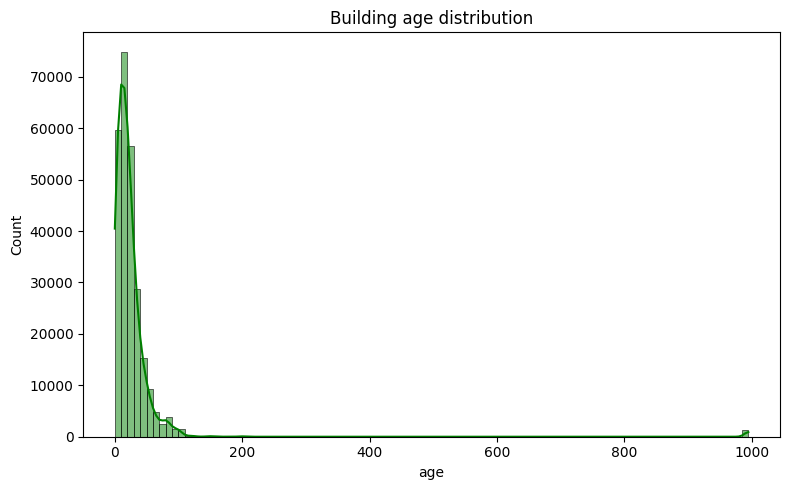

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# age distribution
plt.figure(figsize=(8,5))
sns.histplot(x='age', data=df, color='green', kde=True, bins=100)
plt.title("Building age distribution")
plt.tight_layout()
plt.show()


As we oberseve the Age Distribution, it is right skewed. It has to convert into Normal Distribution

<Axes: >

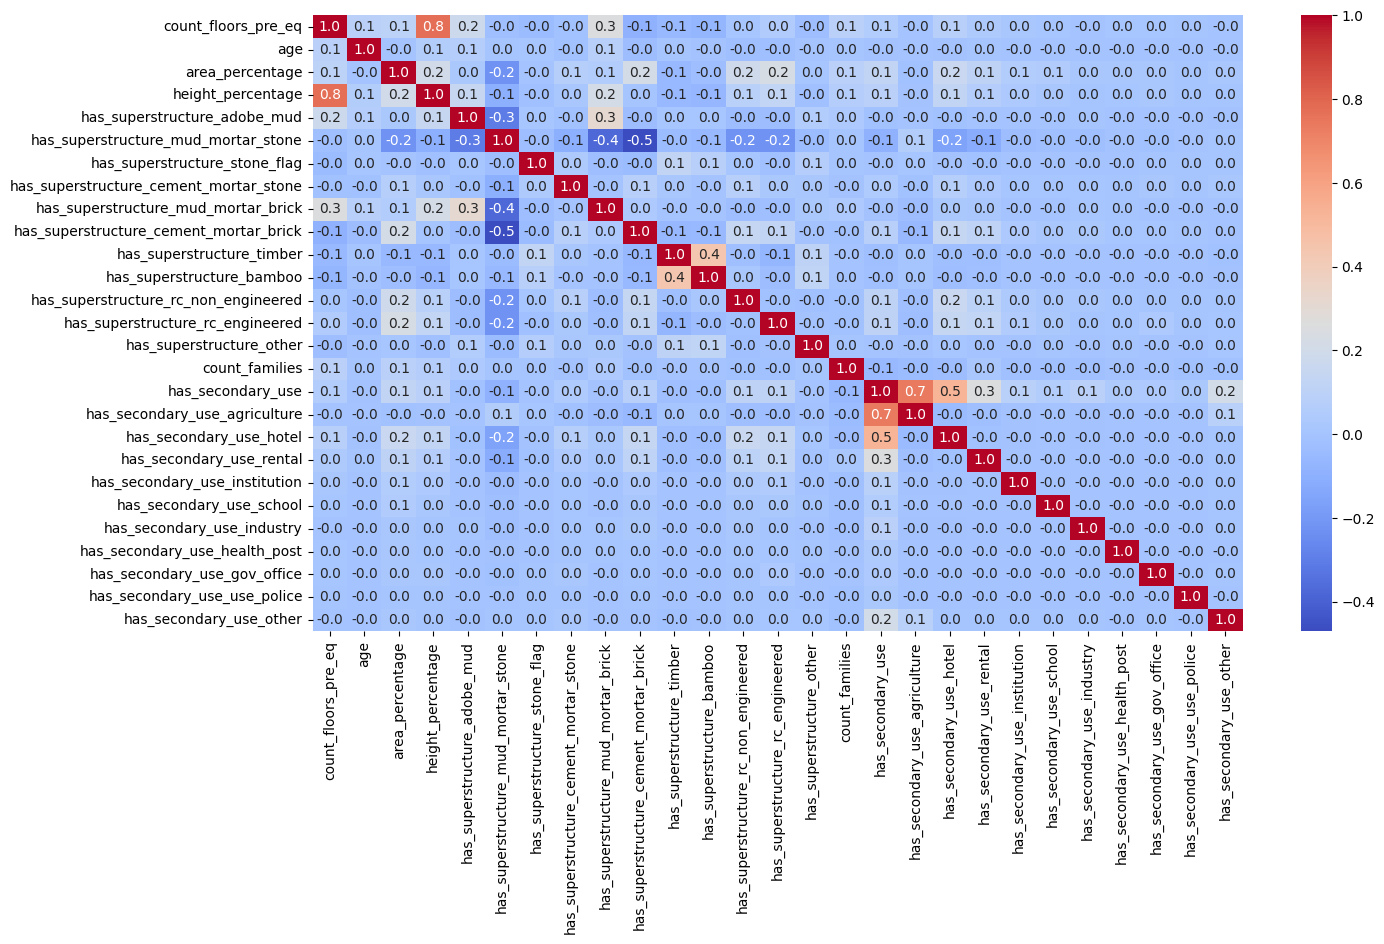

In [17]:
# heatmap
plt.figure(figsize=(15,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=True, fmt=".1f", cbar=True)

From above Heatmap, we obersevd that most of features have neutral or negative correlation and very few have positive.

In [14]:
num_df = X[num_cols]

In [16]:
num_df.shape
num_df.columns

Index(['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other'],
      dtype='object')

In [18]:
binary_cols = []
for cols in num_cols:
    val = X[cols].unique()
    val = list(val)
    if val == [0,1] or val == [1,0]:
        binary_cols.append(cols)

In [19]:
for col in binary_cols:
    print(f"{col}", df[col].unique())

has_superstructure_adobe_mud [0 1]
has_superstructure_mud_mortar_stone [1 0]
has_superstructure_stone_flag [0 1]
has_superstructure_cement_mortar_stone [0 1]
has_superstructure_mud_mortar_brick [0 1]
has_superstructure_cement_mortar_brick [0 1]
has_superstructure_timber [0 1]
has_superstructure_bamboo [0 1]
has_superstructure_rc_non_engineered [0 1]
has_superstructure_rc_engineered [0 1]
has_superstructure_other [0 1]
has_secondary_use [0 1]
has_secondary_use_agriculture [0 1]
has_secondary_use_hotel [0 1]
has_secondary_use_rental [0 1]
has_secondary_use_institution [0 1]
has_secondary_use_school [0 1]
has_secondary_use_industry [0 1]
has_secondary_use_health_post [0 1]
has_secondary_use_gov_office [0 1]
has_secondary_use_use_police [0 1]
has_secondary_use_other [0 1]


 deleting multiple items from a list syntax:
 new_list = [item for item in original_list if item not in items_to_remove]

In [20]:
non_binary_cols = [item for item in num_cols if item not in binary_cols]
print(non_binary_cols)

['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'count_families']


In [23]:
X[non_binary_cols].tail(3)

,count_floors_pre_eq,age,area_percentage,height_percentage,count_families
260598,3,55,10,6,1
260599,3,35,4,4,1
260600,2,45,5,5,1


In [22]:
# function to find and calculate the outliers in numerical columns
def detect_outliers(data_frame, column):
  q1 = data_frame[column].quantile(0.25)
  q3 = data_frame[column].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr
  outliers = data_frame[(data_frame[column] < lower) | (data_frame[column] > upper)]
  return outliers

In [23]:
# create a dataframe for only numerical features
num_df = pd.DataFrame(X[non_binary_cols])

In [24]:
print(num_df.columns)

Index(['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'count_families'],
      dtype='object')


In [25]:
# apply function to "num_df" dataframe
print("number of outliers: ")
total_outliers = 0
for cols in num_df.columns:
  outliers = detect_outliers(num_df, cols)
  total_outliers += len(outliers)
  print(f"Column {cols}: {len(outliers)}")
print("total outliers = ", total_outliers)
print(f"percetange of outliers = {(total_outliers * 100) / (num_df.shape[0] * num_df.shape[1]):.2f} %")

number of outliers: 
Column count_floors_pre_eq: 103978
Column age: 12499
Column area_percentage: 13557
Column height_percentage: 7843
Column count_families: 34486
total outliers =  172363
percetange of outliers = 13.23 %


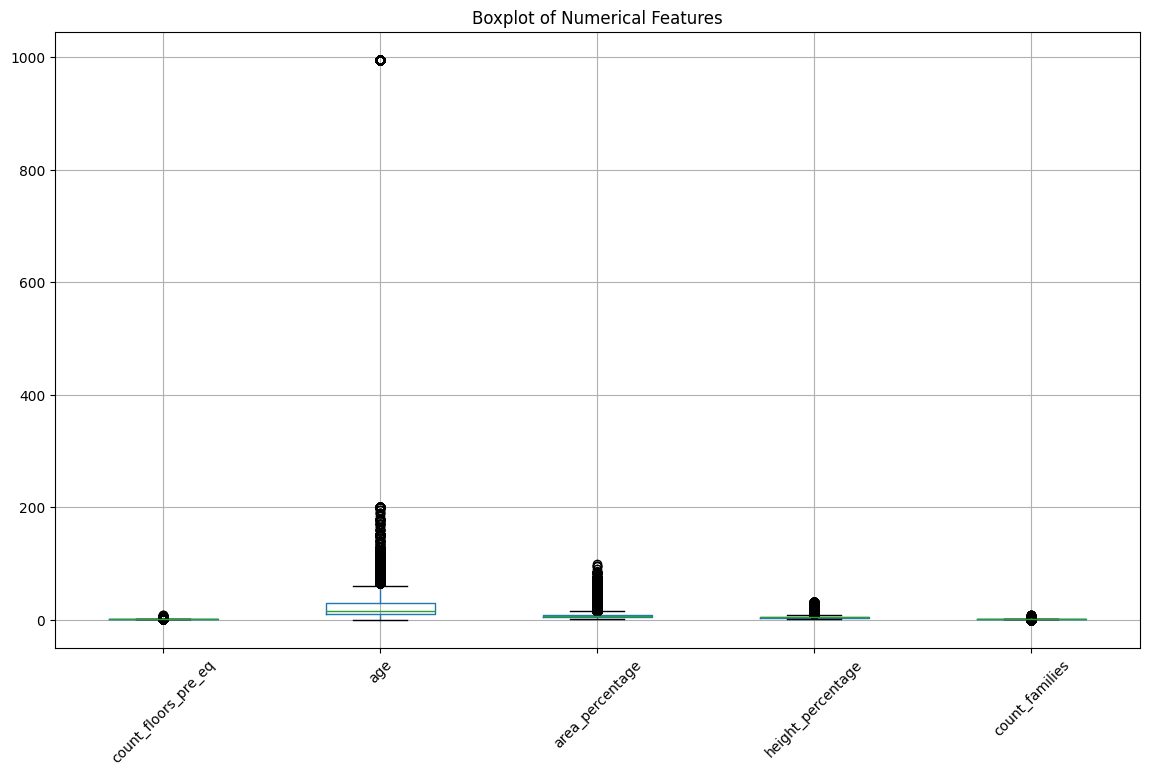

In [28]:
# boxplot
plt.figure(figsize=(14, 8))
df[non_binary_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [29]:
# function to plot histogram
def plot_histogram(data, column, color, bin_size):
    plt.figure(figsize=(12,6))
    sns.histplot(x=column, data=data, kde=True, color=color, bins=bin_size)
    plt.xlabel(f"{column}")
    plt.title(f'{column} distribution')

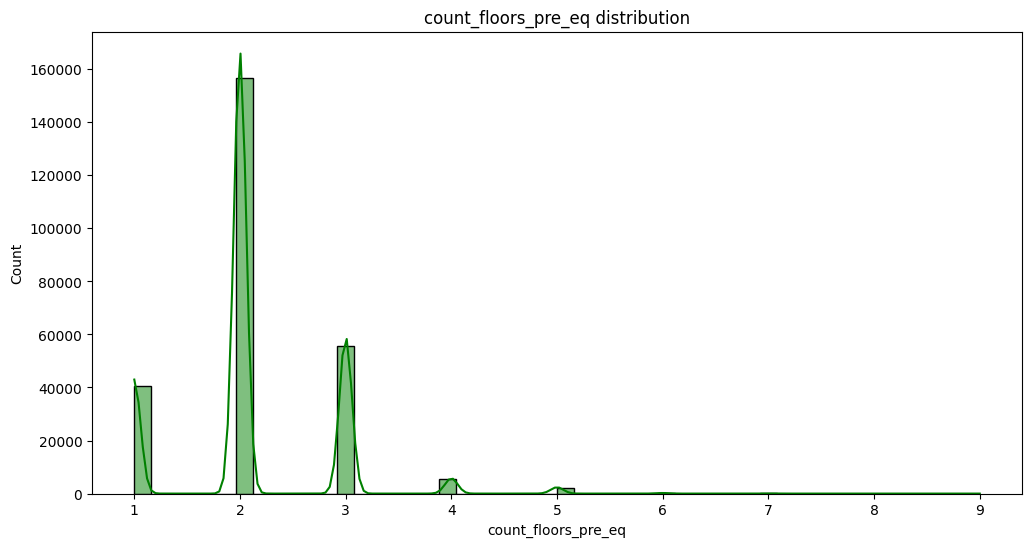

In [30]:
# plot histogram for each column in non_binary_col
plot_histogram(data=num_df, column='count_floors_pre_eq', color='green', bin_size=50)

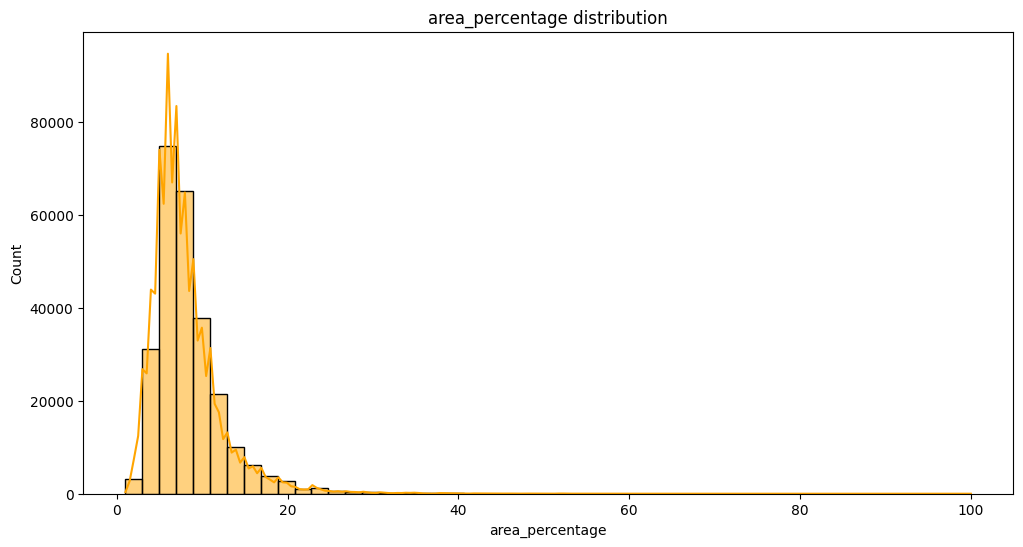

In [31]:
plot_histogram(data=num_df, column='area_percentage', color='orange', bin_size=50)

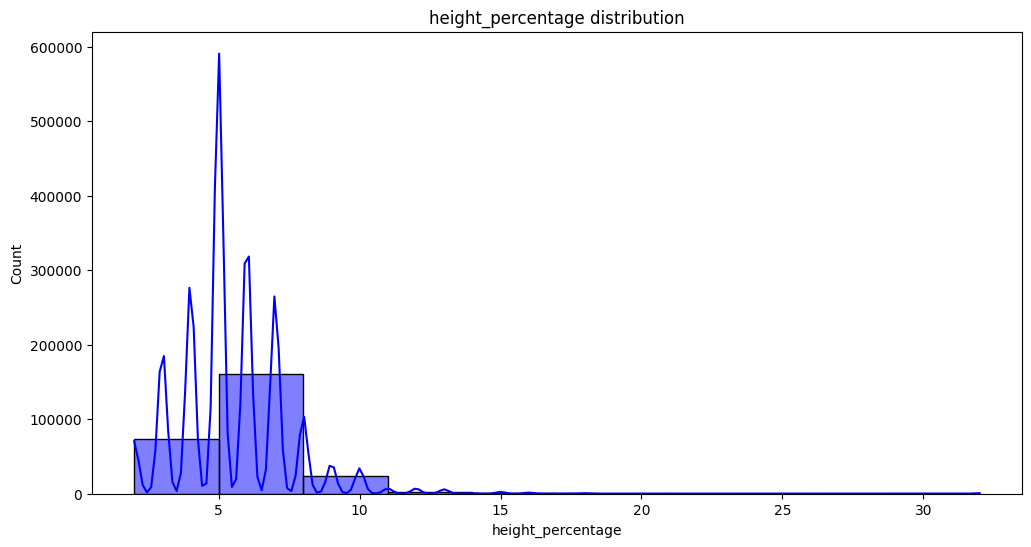

In [32]:
plot_histogram(data=num_df, column='height_percentage', color='blue', bin_size=10)

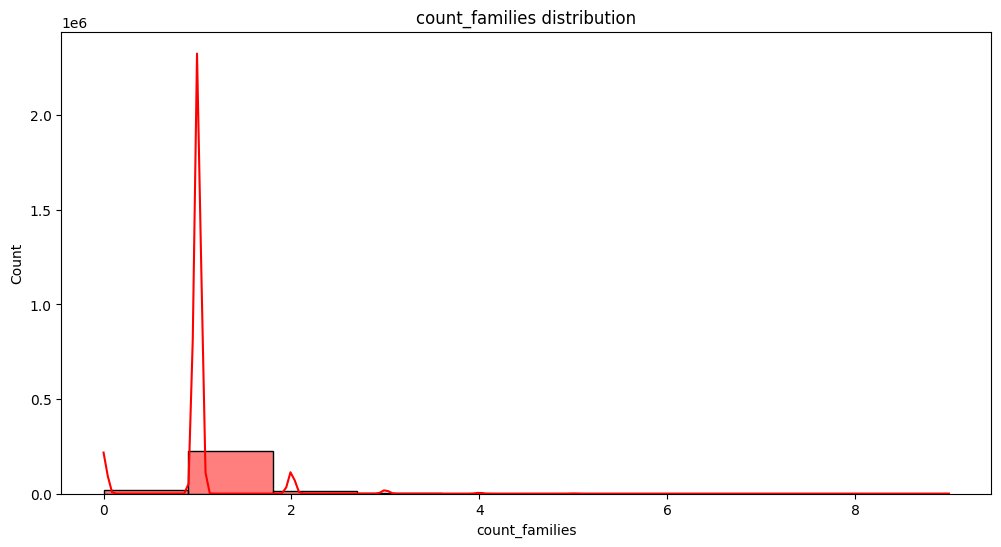

In [33]:
plot_histogram(data=num_df, column='count_families', color='red', bin_size=10)

In [26]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [35]:
X.head()

,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,1,25,5,2,t,r,n,f,j,s,...,0,0,0,0,0,0,0,0,0,0
1,2,0,13,7,t,r,n,f,q,s,...,0,0,0,0,0,0,0,0,0,0
2,2,5,12,6,o,r,q,f,q,s,...,0,0,0,0,0,0,0,0,0,0
3,2,80,5,4,n,r,n,f,q,s,...,0,0,0,0,0,0,0,0,0,0
4,5,40,5,10,t,r,n,f,q,o,...,0,0,0,0,0,0,0,0,0,0


In [27]:
print('total columns = ', len(cat_cols) + len(binary_cols) + len(non_binary_cols))

total columns =  35


number of columns in all list is matching with actual X dataset which means there's no missing column for trainig. We are good to proceed

In [28]:
X.head()

,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,1,25,5,2,t,r,n,f,j,s,...,0,0,0,0,0,0,0,0,0,0
1,2,0,13,7,t,r,n,f,q,s,...,0,0,0,0,0,0,0,0,0,0
2,2,5,12,6,o,r,q,f,q,s,...,0,0,0,0,0,0,0,0,0,0
3,2,80,5,4,n,r,n,f,q,s,...,0,0,0,0,0,0,0,0,0,0
4,5,40,5,10,t,r,n,f,q,o,...,0,0,0,0,0,0,0,0,0,0


In [29]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(X[cat_cols])
encoded

array([[0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.]])

In [30]:
one_hot_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))
print(one_hot_df.head(3))

   land_surface_condition_n  land_surface_condition_o  \
0                       0.0                       0.0   
1                       0.0                       0.0   
2                       0.0                       1.0   

   land_surface_condition_t  foundation_type_h  foundation_type_i  \
0                       1.0                0.0                0.0   
1                       1.0                0.0                0.0   
2                       0.0                0.0                0.0   

   foundation_type_r  foundation_type_u  foundation_type_w  roof_type_n  \
0                1.0                0.0                0.0          1.0   
1                1.0                0.0                0.0          1.0   
2                1.0                0.0                0.0          0.0   

   roof_type_q  ...  plan_configuration_m  plan_configuration_n  \
0          0.0  ...                   0.0                   0.0   
1          0.0  ...                   0.0                  

In [35]:
X.shape

(260601, 35)

In [36]:
len(cat_cols)

8

In [32]:
X_encoded = pd.concat([X, one_hot_df], axis=1)
print(X_encoded.columns)

Index(['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_industry',
       'has_secondary_use_health_post', 'has_secondary_use_gov_off

In [33]:
X_encoded.shape

(260601, 73)

In [40]:
X_encoded = X_encoded.drop(cat_cols, axis=1)

In [41]:
X_encoded.shape

(260601, 65)

In [42]:
X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, test_size=0.25, random_state=42)

In [43]:
print("X_train: ",X_train.shape)
print("X_val: ", X_val.shape)

X_train:  (195450, 65)
X_val:  (65151, 65)


In [44]:
# one hot encoding 
X_train.columns

Index(['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other', 'land_surface_condition_n',
       'land_surface_condition_o', 'land_surface_condition_t',
       'fo

In [46]:
len(y_train)

195450

In [49]:
# function to calculate accuracy and r2 score
def evaluate_model(X_val, y_val, model):
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    return acc, r2

In [52]:
test_df = pd.read_csv('/kaggle/input/earthquake-severity-test-dataset/test_values.csv')
test_df.columns

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_i

In [53]:
building_id = test_df['building_id']

In [54]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86868 entries, 0 to 86867
Data columns (total 39 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   building_id                             86868 non-null  int64 
 1   geo_level_1_id                          86868 non-null  int64 
 2   geo_level_2_id                          86868 non-null  int64 
 3   geo_level_3_id                          86868 non-null  int64 
 4   count_floors_pre_eq                     86868 non-null  int64 
 5   age                                     86868 non-null  int64 
 6   area_percentage                         86868 non-null  int64 
 7   height_percentage                       86868 non-null  int64 
 8   land_surface_condition                  86868 non-null  object
 9   foundation_type                         86868 non-null  object
 10  roof_type                               86868 non-null  object
 11  gr

In [58]:
test_df.isnull().sum()

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

In [67]:
# prepare test dataset
def prepare_testdata(test_dataset, encoder):
    test_copy = test_dataset.copy()
    # drop columns
    cols_drop = ['building_id','geo_level_1_id','geo_level_2_id','geo_level_3_id']
    cat_cols = []
    for cols in test_copy.columns:
        if test_copy[cols].dtypes == 'object':
            cat_cols.append(cols)
    print("catrgorical columns:\n", cat_cols)
    test_copy = test_copy.drop(cols_drop, axis=1)
    print("ids dropped!")
    # encoding
    encoded = encoder.transform(test_copy[cat_cols])
    print("encoding done!")
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))
    final_test_df = pd.concat([test_copy,encoded_df], axis=1)
    print("merged dataframes")
    final_test_df = final_test_df.drop(cat_cols, axis=1)
    print("categorical columns removed!")
    print("\n")
    print(final_test_df.columns)
    print("\nshape = ", final_test_df.shape)
    return final_test_df

In [70]:
# function to prepare submission file
def submit(trained_model, test_data, building_id, file_name):
    pred = trained_model.predict(test_data)
    file = pd.DataFrame({
         "building_id" : [building_id],
         "damage_grade" : [pred]
    })
    print(file.head(5))
    file.to_csv(file_name, index=False)
    print(f"{file_name} saved successfully!")

In [51]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, verbose=True, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_acc, rf_r2 = evaluate_model(X_val, y_val, rf_model)
print("rf model evaluation: ")
print(f"accuracy = {rf_acc:.4f} %\nr2 score = {rf_r2:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    9.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s


rf model evaluation: 
accuracy = 0.5792 %
r2 score = -0.1318


[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.4s finished


In [68]:
test_data = prepare_testdata(test_dataset=test_df, encoder=encoder)

catrgorical columns:
 ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
ids dropped!
encoding done!
merged dataframes
categorical columns removed!


Index(['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secon

In [71]:
submit(trained_model=rf_model, test_data=test_data, building_id=building_id, file_name='submission_1.csv')

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s


                                         building_id  \
0  0         300051
1          99355
2         89...   

                                        damage_grade  
0  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...  
submission_1.csv saved successfully!


[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.4s finished


In [48]:
from sklearn.model_selection import GridSearchCV

# rf model
rf_model = RandomForestClassifier()

# dictionary of hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5,7,10]
}

grid_search_rf = GridSearchCV(rf_model, param_grid=param_grid, cv=5, verbose=True)
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


KeyboardInterrupt: 

In [44]:
one_hot_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))
print(one_hot_df)

        land_surface_condition_n  land_surface_condition_o  \
0                            0.0                       0.0   
1                            0.0                       0.0   
2                            0.0                       0.0   
3                            0.0                       0.0   
4                            0.0                       0.0   
...                          ...                       ...   
195445                       0.0                       0.0   
195446                       0.0                       0.0   
195447                       1.0                       0.0   
195448                       1.0                       0.0   
195449                       0.0                       0.0   

        land_surface_condition_t  foundation_type_h  foundation_type_i  \
0                            1.0                0.0                0.0   
1                            1.0                0.0                0.0   
2                            1.0 

In [45]:
one_hot_df.head()

,land_surface_condition_n,land_surface_condition_o,land_surface_condition_t,foundation_type_h,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_n,roof_type_q,...,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_a,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [46]:
for col in cat_cols:
    print(f"{col}", df[col].unique())

land_surface_condition ['t' 'o' 'n']
foundation_type ['r' 'w' 'u' 'i' 'h']
roof_type ['n' 'q' 'x']
ground_floor_type ['f' 'x' 'v' 'z' 'm']
other_floor_type ['j' 'q' 'x' 's']
position ['s' 'o' 't' 'j']
plan_configuration ['d' 'q' 's' 'u' 'c' 'a' 'o' 'm' 'n' 'f']
legal_ownership_status ['v' 'a' 'r' 'w']


In [47]:
X_train_copy = X_train_copy.drop(cat_cols, axis=1)

In [48]:
X_train_copy.head()

,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
66737,2,10,11,6,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
9080,3,0,17,10,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
41043,2,40,10,5,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
90163,2,50,7,5,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
225250,3,25,5,8,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [50]:
# merge encoded dataset and train dataset
X_train_encoded = pd.concat([X_train_copy, one_hot_df], axis=1)
print(X_train_encoded.columns)

Index(['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other', 'land_surface_condition_n',
       'land_surface_condition_o', 'land_surface_condition_t',
       'fo

In [52]:
X_train_encoded.shape

(244240, 65)